In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import plotly.express as px
import json
import re

In [2]:
#flying squirrels data 
flying_squirrels = gpd.read_file('data/HBF_85817_geo_u (1).gpkg')

flying_squirrels = flying_squirrels[::-1].reset_index(drop=True)

#filter flying squirrel observations after 2000
flying_squirrels_2000 = flying_squirrels[flying_squirrels['year'] >= 2000]
flying_squirrels_2000

#flying_squirrels_2000['year'] = flying_squirrels_2000['year'].astype(str)

#flying_squirrels_2000['formatted_date_time'] = pd.to_datetime(flying_squirrels_2000['formatted_date_time'])
#flying_squirrels_2000['date'] = flying_squirrels_2000['formatted_date_time'].dt.strftime('%d.%m.%Y')

,taxonomic_order,formatted_taxon_name,abundance_verbatim,formatted_date_time,country,bio_province_interpreted,locality,collection_name,team,year,geometry
1239,64441,Siberian Flying Squirrel — Pteromys volans,9,2000-01-01,Suomi,"Etelä-Häme (EH), Etelä-Karjala (EK), Etelä-Sav...",NaN,Wildlife triangle,NaN,2000,POINT (26.54583 60.65919)
1240,64441,Siberian Flying Squirrel — Pteromys volans,5,2000-01-01,Suomi,"Etelä-Häme (EH), Uusimaa (U)",NaN,Wildlife triangle,NaN,2000,POINT (25.63133 60.65297)
1241,64441,Siberian Flying Squirrel — Pteromys volans,11,2000-01-01,Suomi,"Etelä-Häme (EH), Uusimaa (U), Varsinais-Suomi (V)",NaN,Wildlife triangle,NaN,2000,POINT (24.71744 60.64051)
1242,64441,Siberian Flying Squirrel — Pteromys volans,4,2000-01-01,Suomi,Uusimaa (U),NaN,Wildlife triangle,NaN,2000,POINT (25.65002 60.20418)
1243,64441,Siberian Flying Squirrel — Pteromys volans,4,2000-01-01,Suomi,"Uusimaa (U), Varsinais-Suomi (V)",NaN,Wildlife triangle,NaN,2000,POINT (23.84819 60.17359)
...,...,...,...,...,...,...,...,...,...,...,...
9969,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-13 [12:07-12:07],Suomi,Uusimaa (U),NaN,"Lajitietokeskus/FinBIF - Notebook, general obs...",Otso Häärä,2024,POINT (24.93557 60.29196)
9970,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),NaN,Löydös Open Finnish Observation Database,Kristiina Boström-Förström,2024,POINT (22.97703 59.77408)
9971,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),NaN,Löydös Open Finnish Observation Database,kristiina boström-förström,2024,POINT (22.97703 59.77408)
9972,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),"Eläintarhan koirapuisto, Töölö",Löydös Open Finnish Observation Database,NaN,2024,POINT (25.01864 60.11016)


In [3]:
#finnish municipalities data as WFS
address = url = (
    "https://paituli.csc.fi/geoserver/wfs?"
    "service=WFS&version=2.0.0&request=GetFeature&"
    "typeNames=paituli:mml_hallinto_2025_milj_tk&"
    "outputFormat=application/json"
)

gdf = gpd.read_file(url)

gdf

,id,GML_ID,NATCODE,NAMEFIN,NAMESWE,LANDAREA,FRESHWAREA,SEAWAREA,TOTALAREA,geometry
0,mml_hallinto_2025_milj_tk.1,1601200031,020,Akaa,Akaa,293.29,21.09,0.00,314.38,"MULTIPOLYGON (((325843.84 6794740.82, 326294.8..."
1,mml_hallinto_2025_milj_tk.2,1601200345,976,Ylitornio,Övertorneå,2030.68,182.09,0.00,2212.77,"MULTIPOLYGON (((409655.43 7405471.52, 409669.9..."
2,mml_hallinto_2025_milj_tk.3,1601200393,694,Riihimäki,Riihimäki,121.01,4.54,0.00,125.55,"MULTIPOLYGON (((376693.22 6742123.69, 379117.2..."
3,mml_hallinto_2025_milj_tk.4,1601200188,905,Vaasa,Vasa,364.88,4.71,205.55,575.14,"MULTIPOLYGON (((252865.53 7009685.72, 253102.1..."
4,mml_hallinto_2025_milj_tk.5,1601200089,062,Föglö,Föglö,135.37,0.20,1733.50,1869.07,"MULTIPOLYGON (((140254.49 6685207.15, 140191.9..."
...,...,...,...,...,...,...,...,...,...,...
303,mml_hallinto_2025_milj_tk.304,1601200121,081,Hartola,Hartola,542.97,132.52,0.00,675.49,"MULTIPOLYGON (((439745.44 6848204.74, 442340.8..."
304,mml_hallinto_2025_milj_tk.305,1601200369,245,Kerava,Kervo,30.64,0.15,0.00,30.79,"MULTIPOLYGON (((398323.4 6700627.86, 398868.04..."
305,mml_hallinto_2025_milj_tk.306,1601200204,140,Iisalmi,Idensalmi,763.01,109.16,0.00,872.17,"MULTIPOLYGON (((514296.36 7061011.43, 515521.3..."
306,mml_hallinto_2025_milj_tk.307,1601200229,584,Perho,Perho,747.86,27.32,0.00,775.18,"MULTIPOLYGON (((389814.31 7018219.87, 387296.0..."


In [4]:
#municipalities in the Uusimaa region
municipalities = [
    "Espoo", "Helsinki", "Hyvinkää", "Järvenpää", "Karkkila",
    "Kauniainen", "Kerava", "Kirkkonummi", "Lohja", "Mäntsälä",
    "Nurmijärvi", "Pornainen", "Sipoo", "Siuntio", "Tuusula",
    "Vantaa", "Vihti",
    "Hanko", "Inkoo", "Raasepori",
    "Lapinjärvi", "Loviisa",
    "Askola", "Myrskylä", "Porvoo", "Pukkila"
]

#filter municipalities in Uusimaa 
name_col = "NAMEFIN"

uusimaa_kunnat = gdf[gdf[name_col].isin(municipalities)].copy()
uusimaa = uusimaa_kunnat.dissolve()

<Axes: >

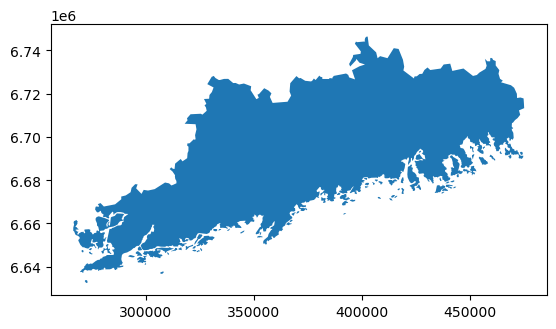

In [5]:
uusimaa.plot()

In [6]:
#reproject to projected CRS
uusimaa = uusimaa.to_crs(3857)
flying_squirrels_2000 = flying_squirrels_2000.to_crs(3857)

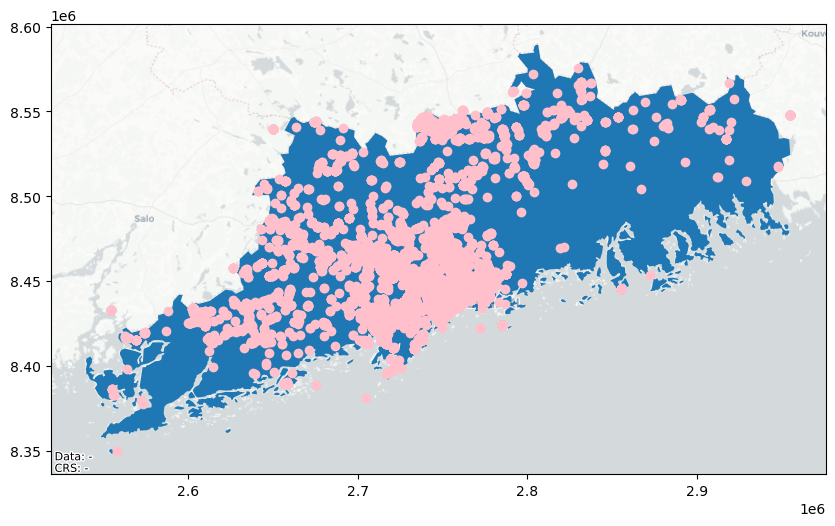

In [7]:
fig, ax = plt.subplots(figsize=(10,10))

uusimaa.plot(ax=ax)
flying_squirrels_2000.plot(ax=ax, color='Pink')

ctx.add_basemap(ax, crs=3857 , source=ctx.providers.CartoDB.Positron,
                      attribution=("Data: - \nCRS: -"))

In [8]:
#flying squirrel data: convert dates to datetime
def extract_date_only(s):
    if not isinstance(s, str):
        return s
    match = re.search(r'\d{4}-\d{2}-\d{2}', s)
    if match:
        return match.group(0)
    return s  # fallback if no match
    
flying_squirrels_2000['clean_date_str'] = flying_squirrels_2000['formatted_date_time'].apply(extract_date_only)
flying_squirrels_2000['clean_date'] = pd.to_datetime(flying_squirrels_2000['clean_date_str'], errors='coerce')
flying_squirrels_2000['date'] = flying_squirrels_2000['clean_date'].dt.strftime('%d.%m.%Y')
flying_squirrels_2000['Observation date'] = flying_squirrels_2000['date']

#abundance column edit
flying_squirrels_2000['abundance'] = flying_squirrels_2000['abundance_verbatim']

flying_squirrels_2000['abundance'] = flying_squirrels_2000['abundance'].astype(str)

flying_squirrels_2000["abundance_num"] = (
    flying_squirrels_2000["abundance_verbatim"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
)
flying_squirrels_2000["abundance_round"] = flying_squirrels_2000["abundance_num"].round()
flying_squirrels_2000["abundance_text"] = flying_squirrels_2000["abundance_num"].round(2).astype(str)
flying_squirrels_2000["Abundance"] = (
    flying_squirrels_2000["abundance_num"]
    .round(2)
    .astype("string")
    .fillna("unknown")
)

flying_squirrels_2000

,taxonomic_order,formatted_taxon_name,abundance_verbatim,formatted_date_time,country,bio_province_interpreted,locality,collection_name,team,year,geometry,clean_date_str,clean_date,date,Observation date,abundance,abundance_num,abundance_round,abundance_text,Abundance
1239,64441,Siberian Flying Squirrel — Pteromys volans,9,2000-01-01,Suomi,"Etelä-Häme (EH), Etelä-Karjala (EK), Etelä-Sav...",NaN,Wildlife triangle,NaN,2000,POINT (2955068.501 8547984.147),2000-01-01,2000-01-01,01.01.2000,01.01.2000,9,9.0,9.0,9.0,9.0
1240,64441,Siberian Flying Squirrel — Pteromys volans,5,2000-01-01,Suomi,"Etelä-Häme (EH), Uusimaa (U)",NaN,Wildlife triangle,NaN,2000,POINT (2853266.827 8546571.899),2000-01-01,2000-01-01,01.01.2000,01.01.2000,5,5.0,5.0,5.0,5.0
1241,64441,Siberian Flying Squirrel — Pteromys volans,11,2000-01-01,Suomi,"Etelä-Häme (EH), Uusimaa (U), Varsinais-Suomi (V)",NaN,Wildlife triangle,NaN,2000,POINT (2751533.168 8543742.544),2000-01-01,2000-01-01,01.01.2000,01.01.2000,11,11.0,11.0,11.0,11.0
1242,64441,Siberian Flying Squirrel — Pteromys volans,4,2000-01-01,Suomi,Uusimaa (U),NaN,Wildlife triangle,NaN,2000,POINT (2855346.609 8445336.615),2000-01-01,2000-01-01,01.01.2000,01.01.2000,4,4.0,4.0,4.0,4.0
1243,64441,Siberian Flying Squirrel — Pteromys volans,4,2000-01-01,Suomi,"Uusimaa (U), Varsinais-Suomi (V)",NaN,Wildlife triangle,NaN,2000,POINT (2654768.59 8438487.611),2000-01-01,2000-01-01,01.01.2000,01.01.2000,4,4.0,4.0,4.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9969,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-13 [12:07-12:07],Suomi,Uusimaa (U),NaN,"Lajitietokeskus/FinBIF - Notebook, general obs...",Otso Häärä,2024,POINT (2775814.955 8465028.176),2024-03-13,2024-03-13,13.03.2024,13.03.2024,1,1.0,1.0,1.0,1.0
9970,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),NaN,Löydös Open Finnish Observation Database,Kristiina Boström-Förström,2024,POINT (2557791.614 8349610.585),2024-03-20,2024-03-20,20.03.2024,20.03.2024,1,1.0,1.0,1.0,1.0
9971,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),NaN,Löydös Open Finnish Observation Database,kristiina boström-förström,2024,POINT (2557791.614 8349610.585),2024-03-20,2024-03-20,20.03.2024,20.03.2024,1,1.0,1.0,1.0,1.0
9972,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),"Eläintarhan koirapuisto, Töölö",Löydös Open Finnish Observation Database,NaN,2024,POINT (2785062.488 8424304.967),2024-03-20,2024-03-20,20.03.2024,20.03.2024,1,1.0,1.0,1.0,1.0


In [9]:
#data is in projected CRS (3857)
#compute centroids 
centroids = flying_squirrels_2000.geometry.centroid
centroids_gdf = flying_squirrels_2000.copy()
centroids_gdf['geometry'] = centroids

#convert centroids to geographic CRS
centroids_geo = centroids_gdf.to_crs(epsg=4326)

#assign lon and lat from centroids to original GeoDataFrame
flying_squirrels_2000 = flying_squirrels_2000.copy()
flying_squirrels_2000['lon'] = centroids_geo.geometry.x
flying_squirrels_2000['lat'] = centroids_geo.geometry.y

flying_squirrels_2000

,taxonomic_order,formatted_taxon_name,abundance_verbatim,formatted_date_time,country,bio_province_interpreted,locality,collection_name,team,year,...,clean_date,date,Observation date,abundance,abundance_num,abundance_round,abundance_text,Abundance,lon,lat
1239,64441,Siberian Flying Squirrel — Pteromys volans,9,2000-01-01,Suomi,"Etelä-Häme (EH), Etelä-Karjala (EK), Etelä-Sav...",NaN,Wildlife triangle,NaN,2000,...,2000-01-01,01.01.2000,01.01.2000,9,9.0,9.0,9.0,9.0,26.545832,60.659188
1240,64441,Siberian Flying Squirrel — Pteromys volans,5,2000-01-01,Suomi,"Etelä-Häme (EH), Uusimaa (U)",NaN,Wildlife triangle,NaN,2000,...,2000-01-01,01.01.2000,01.01.2000,5,5.0,5.0,5.0,5.0,25.631332,60.652971
1241,64441,Siberian Flying Squirrel — Pteromys volans,11,2000-01-01,Suomi,"Etelä-Häme (EH), Uusimaa (U), Varsinais-Suomi (V)",NaN,Wildlife triangle,NaN,2000,...,2000-01-01,01.01.2000,01.01.2000,11,11.0,11.0,11.0,11.0,24.717443,60.640512
1242,64441,Siberian Flying Squirrel — Pteromys volans,4,2000-01-01,Suomi,Uusimaa (U),NaN,Wildlife triangle,NaN,2000,...,2000-01-01,01.01.2000,01.01.2000,4,4.0,4.0,4.0,4.0,25.650015,60.204177
1243,64441,Siberian Flying Squirrel — Pteromys volans,4,2000-01-01,Suomi,"Uusimaa (U), Varsinais-Suomi (V)",NaN,Wildlife triangle,NaN,2000,...,2000-01-01,01.01.2000,01.01.2000,4,4.0,4.0,4.0,4.0,23.848192,60.173590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9969,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-13 [12:07-12:07],Suomi,Uusimaa (U),NaN,"Lajitietokeskus/FinBIF - Notebook, general obs...",Otso Häärä,2024,...,2024-03-13,13.03.2024,13.03.2024,1,1.0,1.0,1.0,1.0,24.935570,60.291959
9970,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),NaN,Löydös Open Finnish Observation Database,Kristiina Boström-Förström,2024,...,2024-03-20,20.03.2024,20.03.2024,1,1.0,1.0,1.0,1.0,22.977033,59.774082
9971,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),NaN,Löydös Open Finnish Observation Database,kristiina boström-förström,2024,...,2024-03-20,20.03.2024,20.03.2024,1,1.0,1.0,1.0,1.0,22.977033,59.774082
9972,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),"Eläintarhan koirapuisto, Töölö",Löydös Open Finnish Observation Database,NaN,2024,...,2024-03-20,20.03.2024,20.03.2024,1,1.0,1.0,1.0,1.0,25.018642,60.110161


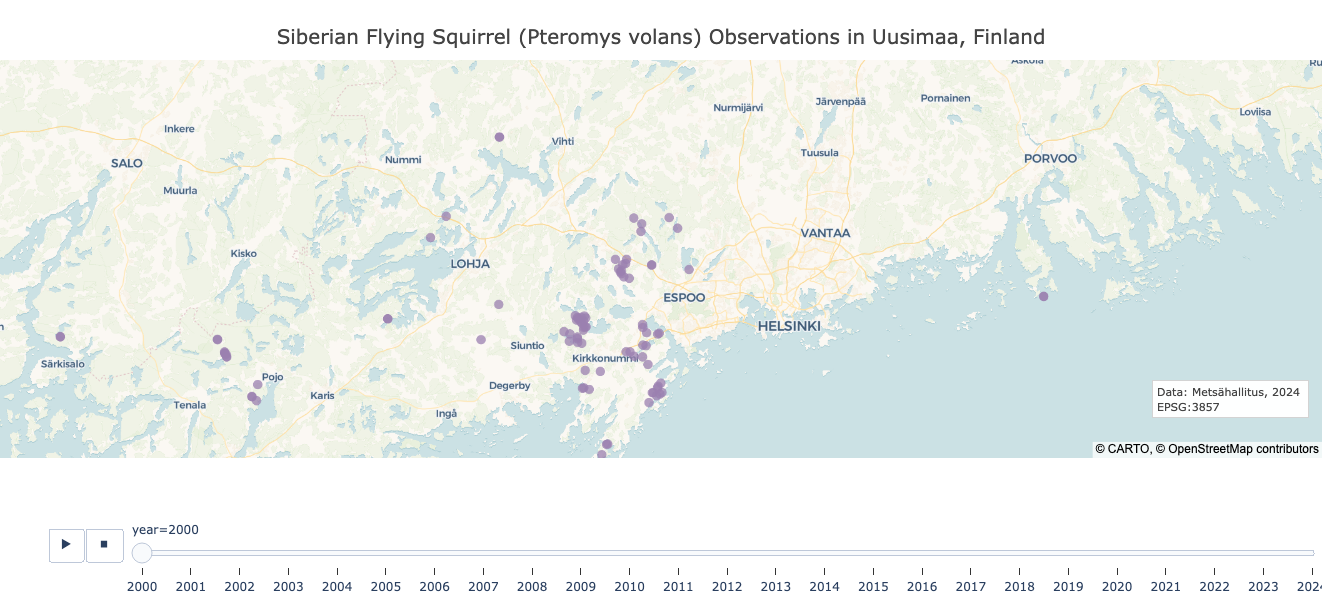

In [10]:
#map flying squirrels
#create an interactive map with adjustments for Finland
fig = px.scatter_map(
    flying_squirrels_2000,
    lat='lat',
    lon='lon',
    color_discrete_sequence=['#9b80b0'],
    hover_name=None,
    hover_data={
        'lat': False,
        'lon': False,
        'year': False,
        'Observation date': True,
        'Abundance': True
    },
    title="Flying squirrels",
    animation_frame='year',
    width=800,
    height=600)

fig.update_layout(
    mapbox_style='open-street-map',
    margin={"r":0, "t":0, "l":0, "b":0},
    title="Flying squirrels"
)

fig.add_annotation(
    text="Data: Metsähallitus, 2024 <br>EPSG:3857",
    xref="paper", yref="paper",
    x=0.99, y=0.10,  
    showarrow=False,
    font=dict(size=11, color="#444444"),
    align="left",
    bgcolor="rgba(255, 255, 255, 0.98)",
    bordercolor="lightgray",
    borderwidth=1,
    borderpad=4
)
fig.update_layout(
    title=dict(
        text="Siberian Flying Squirrel (Pteromys volans) Observations in Uusimaa, Finland",
        x=0.5,  # Centered horizontally
        y=0.95,  # A little lower than default to avoid clipping
        xanchor='center',
        yanchor='top',
        font=dict(size=20, color="#444444")
    ),
    margin=dict(t=60, b=0, l=0, r=0)
)
fig.update_traces(marker=dict(size=10, opacity=0.75))
fig.show()

#write HTML
fig.write_html("flying_squirrels_interactive.html")